In [200]:
import torch
from torch import nn
import matplotlib.pyplot as plt
print("Gpu enabled: ", torch.cuda.is_available())
print(torch.__version__)

Gpu enabled:  True
2.11.0+cu128


In [201]:
weight = 0.5
bias = 0.5

start=0
end=1
step=0.02

X = torch.arange(start,end,step).unsqueeze(1)
y = weight * X + bias


print(X[:10], y[:10])


tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]]) tensor([[0.5000],
        [0.5100],
        [0.5200],
        [0.5300],
        [0.5400],
        [0.5500],
        [0.5600],
        [0.5700],
        [0.5800],
        [0.5900]])


In [202]:
train_split_ratio= int(0.8 * len(X))

train_input, train_output = X[:train_split_ratio] , y[:train_split_ratio]
test_input, test_output = X[train_split_ratio:] , y[train_split_ratio:]

len(train_input), len(train_output), len(test_input), len(test_output)


(40, 40, 10, 10)

In [203]:
def plot_predictions(train_input=train_input, train_output=train_output,test_input=test_input, test_output=test_output, predictions=None):
    plt.figure(figsize=(10,6)) # width , height

    plt.scatter(train_input, train_output, s=8, c="b", label="Training Data")
    plt.scatter(test_input, test_output, s=8, c="g", label="Test Data")

    if predictions is not None:
        plt.scatter(test_input,predictions, s=8, c="r", label="Predictions")

    plt.legend(prop={"size": 14})


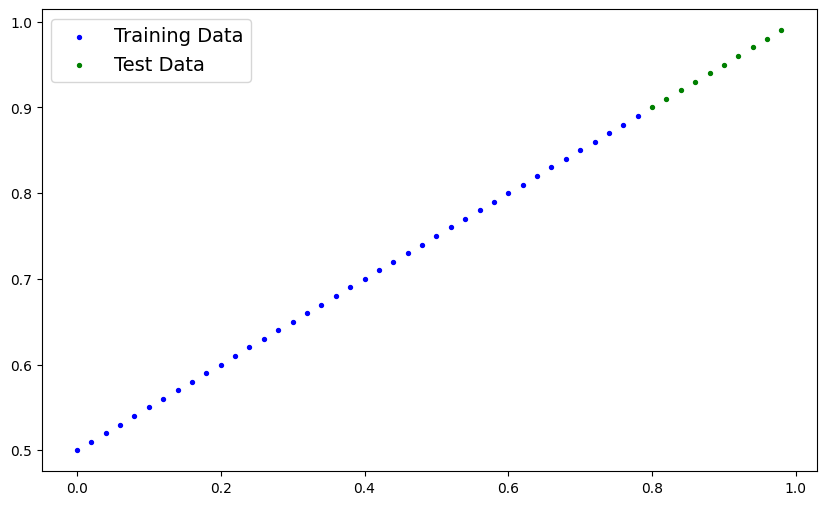

In [204]:
plot_predictions()

In [205]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float32, requires_grad=True))
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float32, requires_grad=True))

    def forward(self, x:torch.Tensor):
        return self.weights*x +self.bias

In [206]:
torch.manual_seed(42)
model = LinearRegression()
print(model.state_dict())
print(list(model.parameters()))

OrderedDict({'weights': tensor([0.3367]), 'bias': tensor([0.1288])})
[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


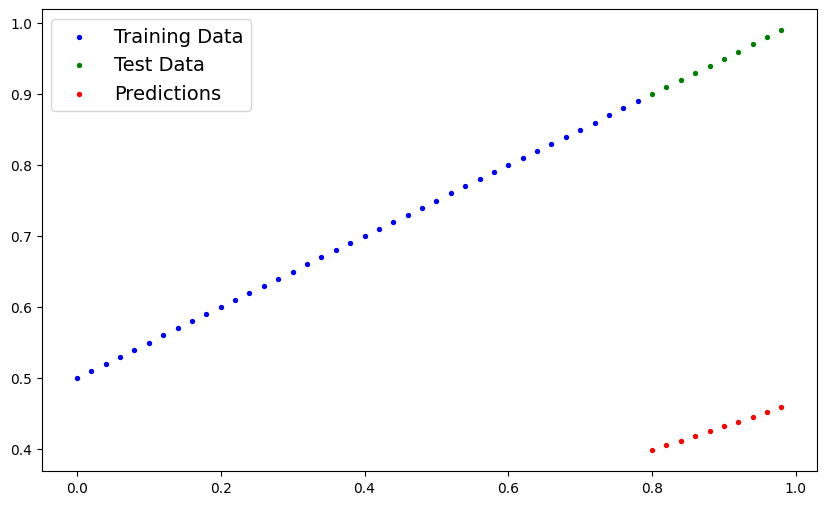

In [207]:
with torch.inference_mode():
    y_preds = model(test_input)

print(y_preds)
plot_predictions(predictions=y_preds)

In [208]:
# Check the predictions
print(f"Number of testing samples: {len(test_input)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


In [209]:
# calculating loss
print(torch.mean(torch.abs(test_output - y_preds))) # same as nn.L1Loss()
print(test_output - y_preds)
loss_fn = nn.L1Loss() # MAE loss is same as L1loss

optimizer = torch.optim.SGD(params=model.parameters(), # parameters of target model to optimize 
                            lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))


tensor(0.5165)
tensor([[0.5018],
        [0.5051],
        [0.5084],
        [0.5116],
        [0.5149],
        [0.5182],
        [0.5214],
        [0.5247],
        [0.5280],
        [0.5312]])


In [210]:
# now here we go for model training, we will update our model parameter(weights, bias) according to our data to match the near exact predictions we want.

epochs=2000
torch.manual_seed(42)
for epoch in range(epochs):
    model.train()

    model_predicton = model(train_input)
    loss = loss_fn(model_predicton,train_output)
    print("Calculating Loss Epoch number", epoch, "Loss: ", loss.detach().numpy())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()

Calculating Loss Epoch number 0 Loss:  0.43488136
Calculating Loss Epoch number 1 Loss:  0.42336035
Calculating Loss Epoch number 2 Loss:  0.41183934
Calculating Loss Epoch number 3 Loss:  0.40031832
Calculating Loss Epoch number 4 Loss:  0.38879734
Calculating Loss Epoch number 5 Loss:  0.37727633
Calculating Loss Epoch number 6 Loss:  0.36575532
Calculating Loss Epoch number 7 Loss:  0.35423434
Calculating Loss Epoch number 8 Loss:  0.34271333
Calculating Loss Epoch number 9 Loss:  0.3311923
Calculating Loss Epoch number 10 Loss:  0.31967133
Calculating Loss Epoch number 11 Loss:  0.30815035
Calculating Loss Epoch number 12 Loss:  0.2966293
Calculating Loss Epoch number 13 Loss:  0.28510836
Calculating Loss Epoch number 14 Loss:  0.27358732
Calculating Loss Epoch number 15 Loss:  0.26206636
Calculating Loss Epoch number 16 Loss:  0.25054535
Calculating Loss Epoch number 17 Loss:  0.23902437
Calculating Loss Epoch number 18 Loss:  0.22750337
Calculating Loss Epoch number 19 Loss:  0.2

tensor([[0.9003],
        [0.9101],
        [0.9200],
        [0.9298],
        [0.9396],
        [0.9494],
        [0.9592],
        [0.9690],
        [0.9788],
        [0.9886]])


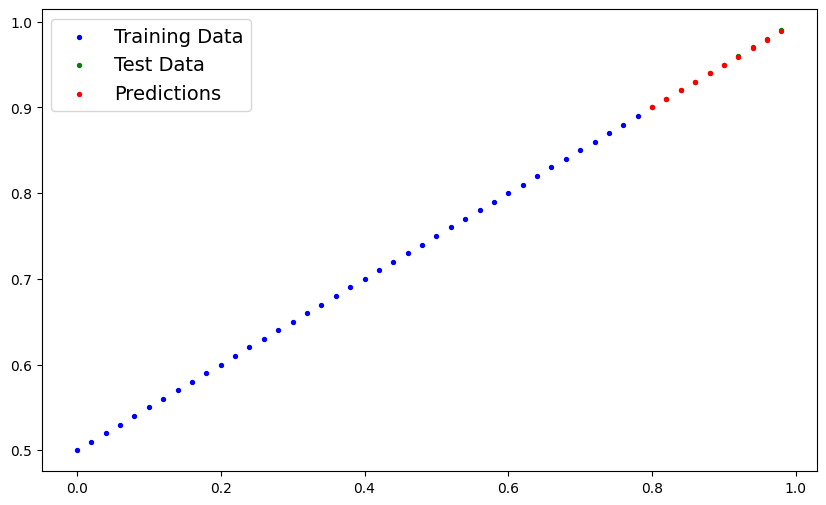

In [ ]:
with torch.inference_mode():
    y_preds = model(test_input)

print(y_preds)
plot_predictions(predictions=y_preds)

In [212]:
print(model.state_dict())
print(list(model.parameters()))

OrderedDict({'weights': tensor([0.4907]), 'bias': tensor([0.5078])})
[Parameter containing:
tensor([0.4907], requires_grad=True), Parameter containing:
tensor([0.5078], requires_grad=True)]
